In [ ]:
!pip install -q kaggle

In [2]:
import os
from google.colab import userdata

# Pass the secret NAME to userdata.get(), not your actual username value
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


print("Credentials loaded successfully!")


Credentials loaded successfully!


In [3]:
!kaggle datasets list -s "cat vs dog"

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
anthonytherrien/dog-vs-cat                             Dog vs Cat                                      377357980  2024-09-28 00:44:01.097000          15087        161  0.875            
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         111943        989  0.875            
karakaggle/kaggle-cat-vs-dog-dataset                   Kaggle: Cat VS Dog Dataset                      825666877  2020-05-01 18:40:09.290000          36864        195  0.625            
arpitjain007/dog-vs-cat-fastai                         Dog vs Cat (fas

In [4]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:08<00:00, 99.6MB/s]



In [5]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [6]:
import os

base_dir = "/content/data/PetImages"

print(os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))

['Cat', 'Dog']
Cat images: 12501
Dog images: 12501


In [7]:
from PIL import Image
import os

classes = ["Cat", "Dog"]

removed = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            os.remove(img_path)
            print(class_name)
            removed += 1

print("Corrupted images removed:", removed)

Cat
Cat


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dog
Dog
Corrupted images removed: 4


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.25),

    Dense(64, activation="relu"),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,836,673 (18.45 MB)

 Trainable params: 4,836,673 (18.45 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
509/625 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5686 - loss: 0.6775

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6269 - loss: 0.6353 - val_accuracy: 0.7269 - val_loss: 0.5424
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7473 - loss: 0.5203 - val_accuracy: 0.7669 - val_loss: 0.4855
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7940 - loss: 0.4460 - val_accuracy: 0.7953 - val_loss: 0.4430
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.8344 - loss: 0.3713 - val_accuracy: 0.8229 - val_loss: 0.3999
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.8768 - loss: 0.2901 - val_accuracy: 0.8213 - val_loss: 0.4036
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9186 - loss: 0.2051 - val_accuracy: 0.8285 - val_loss: 0.4332
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9449 - loss: 0.1427 - val_accuracy: 0.8249 - val_loss: 0.5028
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9659 - loss: 0.0962 - val_accurac

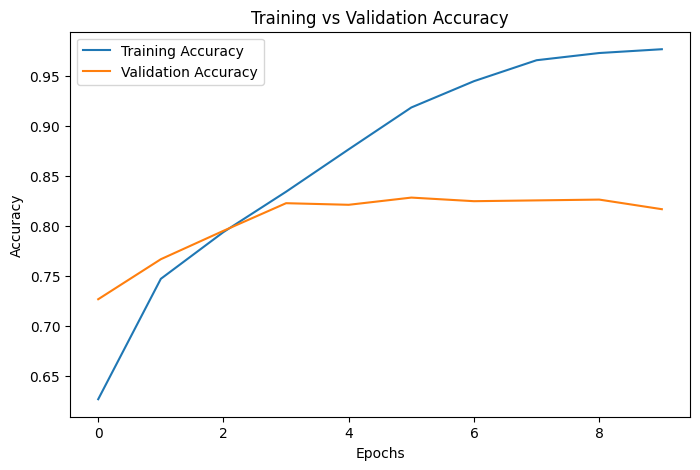

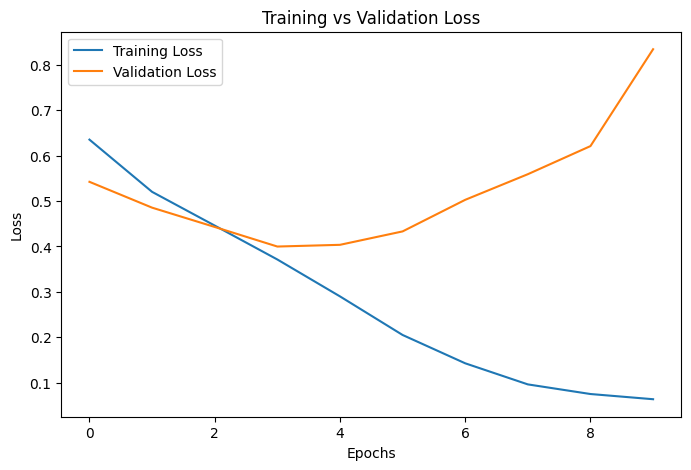

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [13]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8169 - loss: 0.8344
Validation Loss: 0.834449291229248
Validation Accuracy: 0.8169267773628235


In [14]:
model.save("/content/cat_dog_basic_cnn_model.h5")

print("Model saved successfully.")

Model saved successfully.


Saving dog.jpg to dog.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


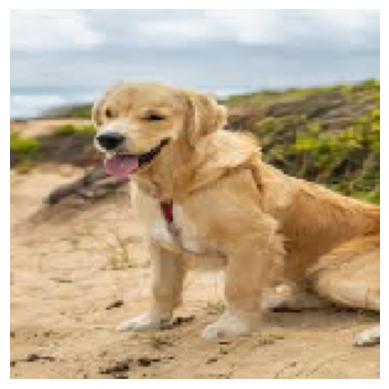

Prediction: Cat
Confidence: 0.5070121


In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path =file_name

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if prediction[0][0] > 0.5:
        print("Prediction: Dog")
        print("Confidence:", prediction[0][0])
    else:
        print("Prediction: Cat")
        print("Confidence:", 1 - prediction[0][0])

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# Make sure IMG_SIZE and model are already defined in your notebook!
# IMG_SIZE = 224

def predict_dog_cat(img):
    # Resize and preprocess the PIL image from Gradio
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img_resized)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Format results
    if prediction > 0.5:
        label = "Dog"
        confidence = float(prediction)
    else:
        label = "Cat"
        confidence = float(1 - prediction)

    return {"Dog": float(prediction), "Cat": float(1 - prediction)}

# Create the Gradio Interface
demo = gr.Interface(
    fn=predict_dog_cat,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Cat vs Dog Classifier",
    description="Upload an image of a cat or a dog to see the model's prediction."
)

# Launch the app inside Colab
demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b95ea3349309e1ee0e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
